In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap
import glob
import json
import _utils

In [2]:
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch

In [3]:
import matplotlib as mpl

In [4]:
mpl.rcParams['xtick.labelsize'] = 7
mpl.rcParams['ytick.labelsize'] = 7
mpl.rcParams['axes.labelsize'] = 7
mpl.rcParams['legend.fontsize'] = 6
mpl.rcParams['legend.frameon'] = False
mpl.rcParams['axes.titlesize'] = 7

In [5]:
plt.rcParams['figure.dpi'] = 200

In [6]:
def plot_map(dat, lons, lats, ax, CMAP = None, VMIN = None, VMAX = None, na_col = "white", 
            label = None, legend = True):
    """ """
    if CMAP is None: 
        CMAP = "viridis"
    
    
    if VMIN is not None:
        p = ax.pcolormesh(lons, lats, dat, vmin = VMIN, vmax = VMAX, transform = ccrs.PlateCarree(), 
                          cmap = CMAP)
    else: 
        p = ax.pcolormesh(lons, lats, dat, transform = ccrs.PlateCarree(), cmap = CMAP)
    
    ax.add_feature(cfeature.LAND.with_scale('110m'), facecolor = na_col)
    ax.add_feature(cfeature.COASTLINE.with_scale('110m'), linewidth = 0.5)   
    if (label is not None) and (legend): 
        cb = plt.colorbar(p, ax = ax, shrink = 0.5, pad = 0.05, location = "bottom")
        cb.set_label(label=label,size = 6)
    elif legend: 
        plt.colorbar(p, ax = ax, shrink = 0.5, location = "bottom")

    ax.set_facecolor(na_col)
    ax.set_extent((-180, 180, -90, 90), crs=ccrs.PlateCarree())
    return(p)

In [7]:
file_dir = "../processed_data/"

In [8]:
common_mask = xr.open_dataset(file_dir+"common_land_mask.nc")
def model_mask(ds):
    return(xr.where(common_mask.__xarray_dataarray_variable__ == 1, ds, np.nan))
    
combined_mask_dat = xr.open_dataset(file_dir+"combined_gauge_model_mask.nc")
def combined_mask(ds):
    return(xr.where(combined_mask_dat.__xarray_dataarray_variable__ >= 2, ds, np.nan))

In [9]:
N = (common_mask.__xarray_dataarray_variable__ == 1).sum().values
N_sub = (combined_mask_dat.__xarray_dataarray_variable__ >= 2).sum().values ## subset of pixels used for time series analysis

## area (cos-latitude) weights, for area-weighted percent-of-grid-cell calculations
weights_land = _utils.area_weights(common_mask.__xarray_dataarray_variable__ == 1)
N_weighted = weights_land.sum().values
weights_sub = _utils.area_weights(combined_mask_dat.__xarray_dataarray_variable__ >= 2)
N_sub_weighted = weights_sub.sum().values

## monthly p95 trends maps over time

In [10]:
start = 1930
end = start+41

In [11]:
gpcc_trend = combined_mask(_utils.read_trends(file_dir, "gpcc", "mon-p095", start, end))

In [12]:
start_years = [1930, 1940, 1950, 1960, 1970, 1979]

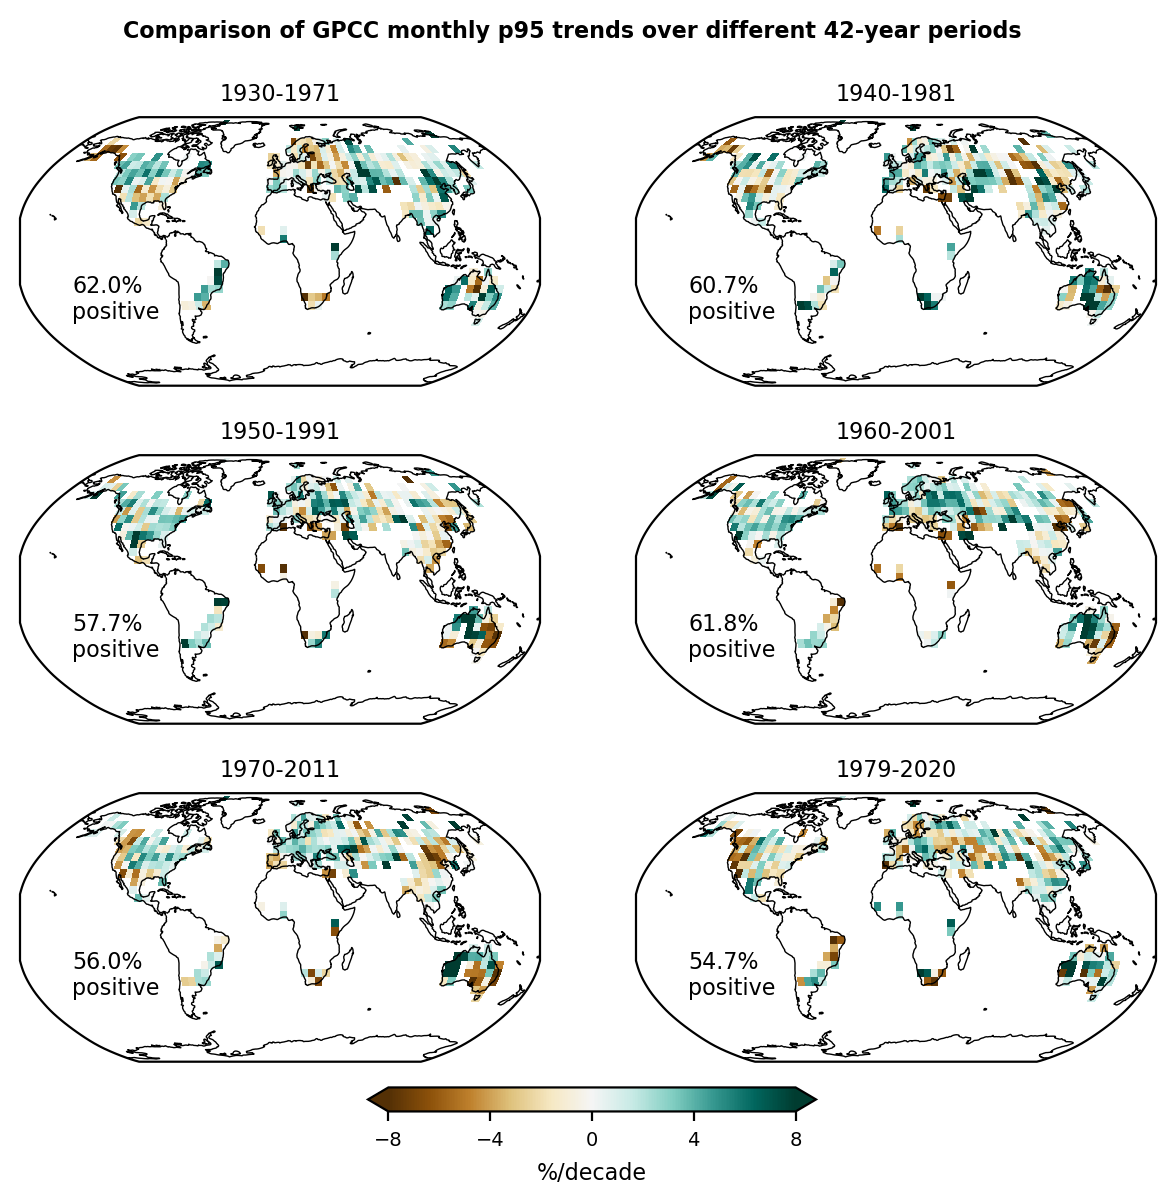

In [13]:
h_tot = 6
h = 1.6/h_tot
w_tot = 6
w = 2.6/w_tot

vmin = -8
vmax = 8
labelsize = 8
titlesize = 8

fig = plt.figure(figsize = (w_tot, h_tot))
plt.suptitle("Comparison of GPCC monthly p95 trends over different 42-year periods", 
             fontsize = 8, fontweight = "bold")
    
ax1 = fig.add_axes([.04, h*2+0.12, w, h], projection = ccrs.Robinson())
ax2 = fig.add_axes([.12+w, h*2+0.12, w, h], projection = ccrs.Robinson())
ax3 = fig.add_axes([.04, h+0.105, w, h], projection = ccrs.Robinson())
ax4 = fig.add_axes([.12+w, h+0.105, w, h], projection = ccrs.Robinson())
ax5 = fig.add_axes([.04, 0.09, w, h], projection = ccrs.Robinson())
ax6 = fig.add_axes([.12+w, 0.09, w, h], projection = ccrs.Robinson())

ax_list = [ax1, ax2, ax3, ax4, ax5, ax6]
for ax, start in zip(ax_list, start_years): 
    end = start+41
    ds= combined_mask(_utils.read_trends(file_dir, "gpcc", "mon-p095", start, end))
    ax.set_title(str(start)+"-"+str(end), size = titlesize)
    p = plot_map(ds, ds.lon, ds.lat, ax,
             CMAP = "BrBG", VMIN = vmin, VMAX = vmax, legend=False)
    ax.text(0.1, 0.25, str(np.round(_utils.weighted_fraction(ds > 0, weights_sub, N_sub_weighted)*100,1))+"%\npositive", 
        size = 8, transform = ax.transAxes)

cbaxes = fig.add_axes([0.33, 0.07, w-0.06, 0.02]) 
cbar = fig.colorbar(p, cax = cbaxes, orientation = "horizontal", extend = "both", ticks=[-8, -4, 0, 4, 8])
cbar.set_label(label = '%/decade', size = 8)
cbar.ax.tick_params(labelsize=7)

plt.savefig("../figures/supp_mon-p95_42year_trend_maps.pdf")
plt.savefig("../figures/supp_mon-p95_42year_trend_maps.png", dpi = 600)

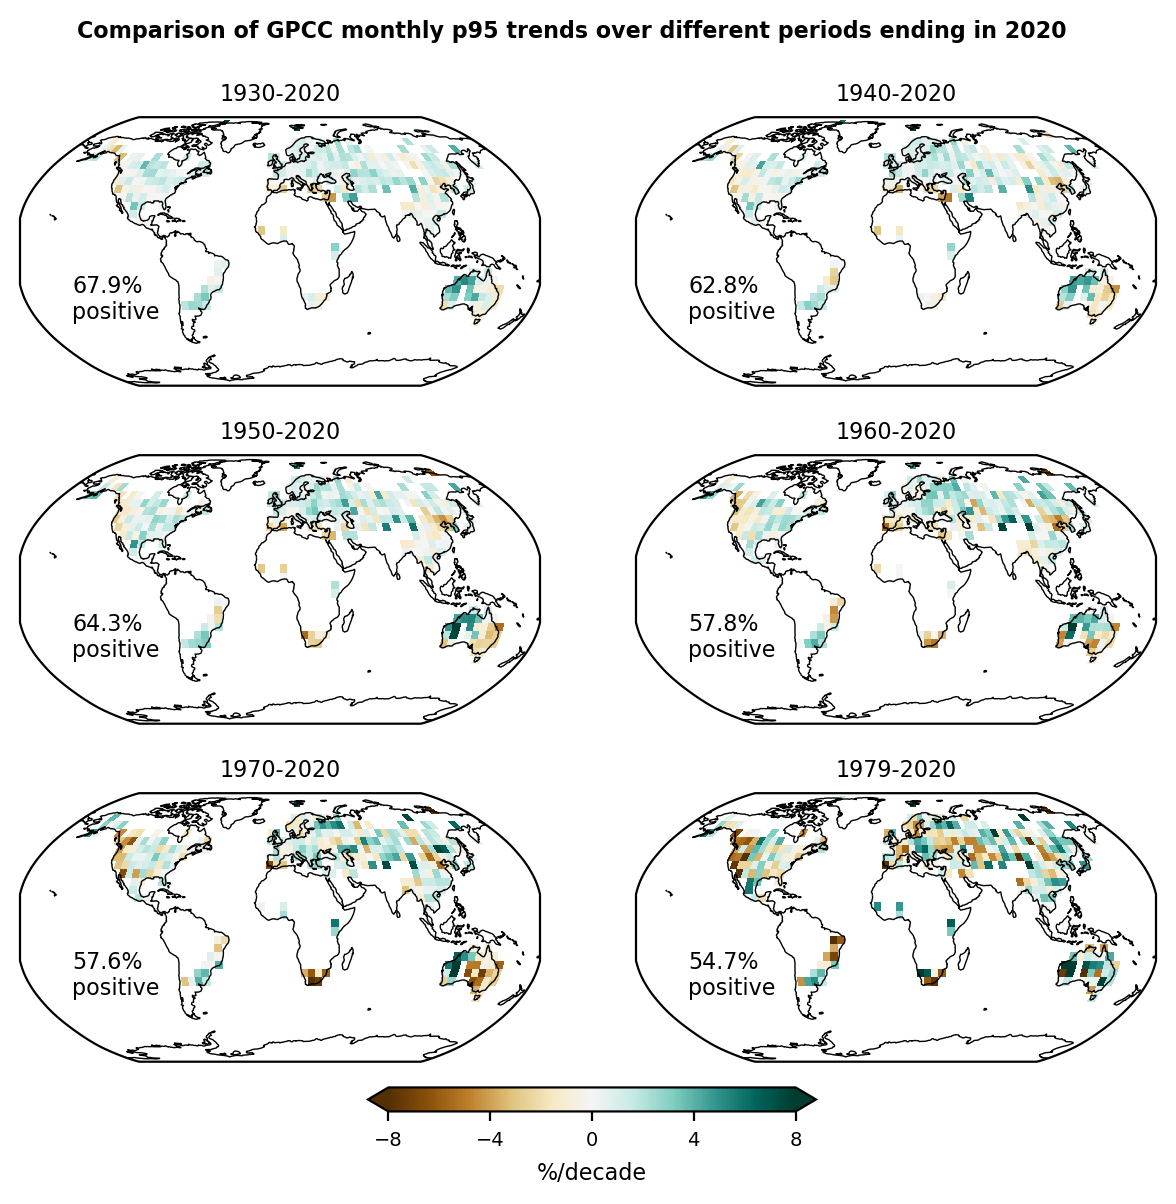

In [14]:
h_tot = 6
h = 1.6/h_tot
w_tot = 6
w = 2.6/w_tot

vmin = -8
vmax = 8
labelsize = 8
titlesize = 8

fig = plt.figure(figsize = (w_tot, h_tot))
plt.suptitle("Comparison of GPCC monthly p95 trends over different periods ending in 2020", 
             fontsize = 8, fontweight = "bold")

ax1 = fig.add_axes([.04, h*2+0.12, w, h], projection = ccrs.Robinson())
ax2 = fig.add_axes([.12+w, h*2+0.12, w, h], projection = ccrs.Robinson())
ax3 = fig.add_axes([.04, h+0.105, w, h], projection = ccrs.Robinson())
ax4 = fig.add_axes([.12+w, h+0.105, w, h], projection = ccrs.Robinson())
ax5 = fig.add_axes([.04, 0.09, w, h], projection = ccrs.Robinson())
ax6 = fig.add_axes([.12+w, 0.09, w, h], projection = ccrs.Robinson())

ax_list = [ax1, ax2, ax3, ax4, ax5, ax6]
for ax, start in zip(ax_list, start_years): 
    end = 2020
    ds= combined_mask(_utils.read_trends(file_dir, "gpcc", "mon-p095", start, end))
    ax.set_title(str(start)+"-"+str(end), size = titlesize)
    p = plot_map(ds, ds.lon, ds.lat, ax, legend = False, CMAP = "BrBG", VMIN = vmin, VMAX = vmax)
    ax.text(0.1, 0.25, str(np.round(_utils.weighted_fraction(ds > 0, weights_sub, N_sub_weighted)*100,1))+"%\npositive", 
        size = 8, transform = ax.transAxes)

cbaxes = fig.add_axes([0.33, 0.07, w-0.06, 0.02]) 
cbar = fig.colorbar(p, cax = cbaxes, orientation = "horizontal", extend = "both", ticks=[-8, -4, 0, 4, 8])
cbar.set_label(label = '%/decade', size = 8)
cbar.ax.tick_params(labelsize=7)

plt.savefig("../figures/supp_mon-p95_2020end_trend_maps.pdf")
plt.savefig("../figures/supp_mon-p95_2020end_trend_maps.png", dpi = 600)

## trend agreement across observational datasets

In [15]:
start = 1979
end = 2020

In [16]:
cpc_trend = model_mask(_utils.read_trends(file_dir, "cpc", "rx1day", start, end))
gpcc_trend = model_mask(_utils.read_trends(file_dir, "gpcc", "mon-p095", start, end))
gpcp_trend = model_mask(_utils.read_trends(file_dir, "gpcp", "mon-p095", start, end))
mswep_rx1day_trend = model_mask(_utils.read_trends(file_dir, "mswep", "rx1day", start, end))
mswep_mon_trend = model_mask(_utils.read_trends(file_dir, "mswep", "mon-p095", start, end))

regen_trend = model_mask(_utils.read_trends(file_dir, "regen", "rx1day", 1979, 2016))

In [17]:
def trends_agree(das):
    """
    das = list of dataarrays with precip trends

    function to calculate whether the sign of trends is in agreement across datasets
    """
    signs = xr.concat([np.sign(da) for da in das], dim="dataset") ## check sign for each dataset
    agree = (signs == signs.isel(dataset=0)).all(dim="dataset")
    return (signs.isel(dataset = 0).where(agree == 1,np.nan))

In [18]:
rx1day_obs_agree = trends_agree([cpc_trend.assign_coords({"dataset": "cpc"}),
                                 regen_trend.assign_coords({"dataset": "regen"})])

rx1day_all_agree = trends_agree([cpc_trend.assign_coords({"dataset": "cpc"}),
                                 regen_trend.assign_coords({"dataset": "regen"}),
             mswep_rx1day_trend.assign_coords({"dataset": "mswep"})])

In [19]:
monp95_obs_agree = trends_agree([gpcc_trend.assign_coords({"dataset": "gpcc"}),
                  gpcp_trend.assign_coords({"dataset": "gpcp"})])

monp95_all_agree = trends_agree([gpcc_trend.assign_coords({"dataset": "gpcc"}),
                  gpcp_trend.assign_coords({"dataset": "gpcp"}),
             mswep_mon_trend.assign_coords({"dataset": "mswep"})])

In [20]:
brown_col = "sienna"
blue_col = "skyblue"

In [21]:
plt.rcParams["text.usetex"] = False

In [22]:
weights_land.where(rx1day_obs_agree.isin([-1, 1])).sum().values/N_weighted

np.float64(0.6281730418486309)

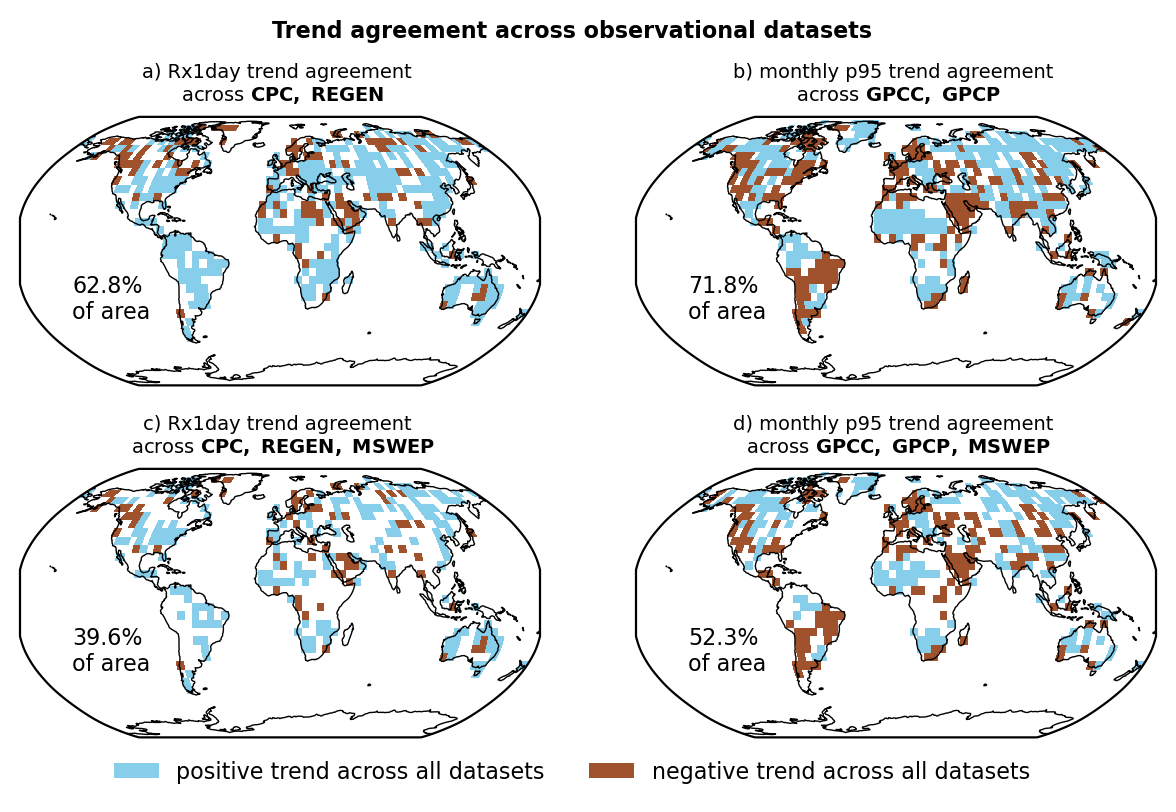

In [23]:
h_tot = 4
h = 1.6/h_tot
w_tot = 6
w = 2.6/w_tot

fig = plt.figure(figsize = (w_tot, h_tot))
plt.suptitle("Trend agreement across observational datasets", fontsize = 8, fontweight = "bold") 

na_col = "white"
cmap = ListedColormap([brown_col, "#dddddd", blue_col])  # -1, 0, 1
norm = BoundaryNorm([-1.5, -0.5, 0.5, 1.5], cmap.N)

ax1 = fig.add_axes([.04, h+0.09, w, h], projection = ccrs.Robinson())
ax2 = fig.add_axes([.12+w, h+0.09, w, h], projection = ccrs.Robinson())
ax3 = fig.add_axes([.04, 0.05, w, h], projection = ccrs.Robinson())
ax4 = fig.add_axes([.12+w, 0.05, w, h], projection = ccrs.Robinson())
ax_list = [ax1, ax2, ax3, ax4]

## TOP LEFT
p = ax1.pcolormesh(rx1day_obs_agree.lon, rx1day_obs_agree.lat, rx1day_obs_agree, transform = ccrs.PlateCarree(), 
                 cmap = cmap, norm = norm) 
ax1.set_title("a) Rx1day trend agreement \n across $\\bf{CPC,\\ REGEN}$", size = 7)
ax1.text(0.1, 0.25, str(np.round(weights_land.where(rx1day_obs_agree.isin([-1, 1])).sum().values/N_weighted*100,1))+"%\nof area", 
        size = 8, transform = ax1.transAxes)

## TOP RIGHT
p = ax2.pcolormesh(monp95_obs_agree.lon, monp95_obs_agree.lat, monp95_obs_agree, transform = ccrs.PlateCarree(), 
                 cmap = cmap, norm = norm)
ax2.set_title("b) monthly p95 trend agreement \n across $\\bf{GPCC,\\ GPCP}$", size = 7)
ax2.text(0.1, 0.25, str(np.round(weights_land.where(monp95_obs_agree.isin([-1, 1])).sum().values/N_weighted*100,1))+"%\nof area", 
        size = 8, transform = ax2.transAxes)

## BOTTOM LEFT 
p = ax3.pcolormesh(rx1day_all_agree.lon, rx1day_all_agree.lat, rx1day_all_agree, transform = ccrs.PlateCarree(), 
                 cmap = cmap, norm = norm) 
ax3.set_title("c) Rx1day trend agreement \n across $\\bf{CPC,\\ REGEN,\\ MSWEP}$", size = 7)
ax3.text(0.1, 0.25, str(np.round(weights_land.where(rx1day_all_agree.isin([-1, 1])).sum().values/N_weighted*100,1))+"%\nof area", 
        size = 8, transform = ax3.transAxes)

## BOTTOM RIGHT
p = ax4.pcolormesh(monp95_all_agree.lon, monp95_all_agree.lat, monp95_all_agree, transform = ccrs.PlateCarree(), 
                 cmap = cmap, norm = norm) 
ax4.set_title("d) monthly p95 trend agreement \n across $\\bf{GPCC,\\ GPCP,\\ MSWEP}$", size = 7)
ax4.text(0.1, 0.25, str(np.round(weights_land.where(monp95_all_agree.isin([-1, 1])).sum().values/N_weighted*100,1))+"%\nof area", 
        size = 8, transform = ax4.transAxes)

for ax in ax_list:
    ax.add_feature(cfeature.LAND.with_scale('110m'), facecolor = na_col)
    ax.add_feature(cfeature.COASTLINE.with_scale('110m'), linewidth = 0.5) 
    ax.set_facecolor(na_col)
    ax.set_extent((-180, 180, -90, 90), crs=ccrs.PlateCarree())

legend_elems = [
        Patch(facecolor=blue_col, label= "positive trend across all datasets"),
        Patch(facecolor=brown_col, label="negative trend across all datasets"),
]
fig.legend(handles=legend_elems, loc="lower center", bbox_to_anchor=(0.5, 0), ncol = 2, fontsize = 8)

plt.savefig("../figures/supp_obs_trend_agreement.pdf")
plt.savefig("../figures/supp_obs_trend_agreement.png", dpi = 600)

In [24]:
rx1day_cpc_mswep = trends_agree([cpc_trend.assign_coords({"dataset": "cpc"}),
                                 mswep_rx1day_trend.assign_coords({"dataset": "mswep"})])
rx1day_regen_mswep = trends_agree([regen_trend.assign_coords({"dataset": "regen"}),
                                 mswep_rx1day_trend.assign_coords({"dataset": "mswep"})])

monp95_gpcc_mswep = trends_agree([gpcc_trend.assign_coords({"dataset": "gpcc"}),
                  mswep_mon_trend.assign_coords({"dataset": "mswep"})])
monp95_gpcp_mswep = trends_agree([gpcp_trend.assign_coords({"dataset": "gpcp"}),
                  mswep_mon_trend.assign_coords({"dataset": "mswep"})])

In [25]:
print("Rx1day trend agreement between CPC, MSWEP:", 
      str(np.round(weights_land.where(rx1day_cpc_mswep.isin([-1, 1])).sum().values/N_weighted*100,1))+"% of area")
print("Rx1day trend agreement between REGEN, MSWEP:", 
      str(np.round(weights_land.where(rx1day_regen_mswep.isin([-1, 1])).sum().values/N_weighted*100,1))+"% of area")
print("monthly p95 trend agreement between GPCC, MSWEP:", 
      str(np.round(weights_land.where(monp95_gpcc_mswep.isin([-1, 1])).sum().values/N_weighted*100,1))+"% of area")
print("monthly p95 trend agreement between GPCP, MSWEP:", 
      str(np.round(weights_land.where(monp95_gpcp_mswep.isin([-1, 1])).sum().values/N_weighted*100,1))+"% of area")

Rx1day trend agreement between CPC, MSWEP: 58.7% of area
Rx1day trend agreement between REGEN, MSWEP: 57.7% of area
monthly p95 trend agreement between GPCC, MSWEP: 68.5% of area
monthly p95 trend agreement between GPCP, MSWEP: 64.3% of area


## Obs vs. model agreement in arid vs. humid regions

In [26]:
ppt_ds = xr.open_dataset("../processed_data/TerraClim_19912020_ppt_5x5.nc")
pet_ds = xr.open_dataset("../processed_data/TerraClim_19912020_pet_5x5.nc")

In [27]:
aridity = (ppt_ds.ppt/pet_ds.pet)
aridity_zones = model_mask(xr.where(
        aridity < 0.05, 0, # 0 = hyper-arid
        xr.where(aridity < 0.5, 1, 2) # 1 = arid/semi-arid, 2 = humid
    ))

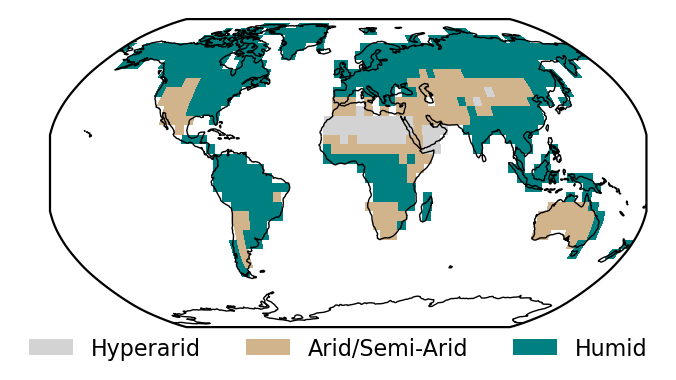

In [28]:
fig = plt.figure(figsize=(4, 2))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.Robinson())

hyperarid_col = "lightgrey"
arid_col = "tan"
humid_col = "teal"

cmap = ListedColormap([hyperarid_col, arid_col, humid_col])  # 0, 1, 2
norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5], cmap.N)

p = ax.pcolormesh(aridity_zones.lon, aridity_zones.lat, aridity_zones, cmap = cmap, norm = norm, 
             transform = ccrs.PlateCarree())
ax.add_feature(cfeature.LAND.with_scale('110m'), facecolor = na_col)
ax.add_feature(cfeature.COASTLINE.with_scale('110m'), linewidth = 0.5) 
ax.set_facecolor(na_col)
ax.set_extent((-180, 180, -90, 90), crs=ccrs.PlateCarree())

legend_elems = [
        Patch(facecolor=hyperarid_col, label= "Hyperarid"),
        Patch(facecolor=arid_col, label="Arid/Semi-Arid"),
    Patch(facecolor=humid_col, label="Humid")
]
fig.legend(handles=legend_elems, loc="lower center", ncol = 3, fontsize = 8)


In [53]:
## calculate percent area above and below for each region and by 15-deg latitude bins? 
def ecdf_by_zone(obs_list, model_list, metric, start, end, zones, zone_names, weights):
    """Area-weighted count/percent of grid cells falling above (ecdf==1) or below (ecdf==0)
    the model distribution, broken out by zone.

    `ecdf_ds` is an ecdf field as produced by calc_ecdf.py (obs trend evaluated against the
    model ensemble's empirical CDF), on the same grid as `zones`/`weights`.
    `weights` should be an area_weights(...) DataArray on the same grid.
    """
    
    rows = []
    for obs in obs_list:
        for model in model_list: 
            ecdf_ds = model_mask(xr.open_dataarray("../processed_data/ecdf/"+\
                                           obs+"_"+model+"_"+metric+"_"+str(start)+"-"+str(end)+"_ecdf.nc"))
            for zone_val, zone_name in zone_names.items():
                zone_mask = zones == zone_val
                zone_weight_total = weights.where(zone_mask, 0).sum().values
        
                above = weights.where(zone_mask & (ecdf_ds == 1), 0).sum().values
                below = weights.where(zone_mask & (ecdf_ds == 0), 0).sum().values
        
                rows.append({
                    "zone": zone_name,
                    "total_weight": zone_weight_total,
                    "above_weight": above,
                    "below_weight": below,
                    "outside_weight": above + below,
                    "pct_above": above / zone_weight_total * 100,
                    "pct_below": below / zone_weight_total * 100,
                    "pct_outside": (above + below) / zone_weight_total * 100,
                    "obs": obs, 
                    "model": model, 
                    "metric": metric,
                })
    return pd.DataFrame(rows)


In [59]:
aridity_names = {0: "hyperarid", 1: "arid_semiarid", 2: "humid"}

In [60]:
ecdf_rx1day_by_aridity = ecdf_by_zone(["cpc", "mswep"], ["cmip-sub", "spear", "mesaclip"], "rx1day", 
                                              start, end, aridity_zones, aridity_names, weights_land)

In [61]:
ecdf_monp95_by_aridity = ecdf_by_zone(["gpcc", "gpcp", "mswep"], ["cmip-sub", "spear", "mesaclip"], "mon-p095", 
                                      start, end, aridity_zones, aridity_names, weights_land)

In [79]:
lat_bins = np.arange(-60, 91, 30)
lat_bin_names = dict(zip(list(range(len(lat_bins))), 
                         [f"{lat_bins[i]} to {lat_bins[i+1]}" for i in range(len(lat_bins)-1)]))
lat_zones = model_mask(xr.DataArray(
        np.digitize(common_mask.lat, lat_bins) - 1,
        coords = {"lat": common_mask.lat}, dims = "lat"
    ).broadcast_like(common_mask))

In [81]:
ecdf_rx1day_by_lat = ecdf_by_zone(["cpc", "mswep"], ["cmip-sub", "spear", "mesaclip"], "rx1day", 
                                              start, end, lat_zones, lat_bin_names, weights_land)
ecdf_monp95_by_lat = ecdf_by_zone(["gpcc", "gpcp", "mswep"], ["cmip-sub", "spear", "mesaclip"], "mon-p095", 
                                      start, end, lat_zones, lat_bin_names, weights_land)